# 4.2 Total regulatory variance: ClinGen HI vs Background (polyA+ RNA-seq)

**Research question:** Do ClinGen haploinsufficient genes show lower total predicted regulatory
variance (Vg) than matched Background genes?

**Score mode:** polyA+ RNA-seq only (`protocol_group == 'polyA_plus_rna_seq'`).
All files are SNP-only (indels excluded at the scoring pipeline level).
Gene-level Vg is loaded directly from the pre-filtered `*_polya.parquet` files via `config.GENE_PATHS`.


In [8]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from scipy.stats import mannwhitneyu

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 140

VG_FLOOR = 1e-12


def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')


PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Use the pre-filtered polyA+ parquet paths from config — no archive, no raw paths.
from config import SOURCE_PALETTE, GENE_PATHS, VARIANT_PATHS
from utils.plot_utils import save_plot

NOTEBOOK_NAME = '4_2_total_vg_global_comparison'
FIG_DIR = PROJECT_ROOT / '10_THESIS' / 'FIGURES_FOR_THESIS'
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ORDER = ['background', 'clingen']
DATASET_DISPLAY = {'background': 'Background', 'clingen': 'ClinGen HI'}
DATASET_PALETTE = {
    DATASET_DISPLAY['background']: SOURCE_PALETTE['background'],
    DATASET_DISPLAY['clingen']:    SOURCE_PALETTE['clingen'],
}

print(f'Project root: {PROJECT_ROOT}')
print(f'Figure dir:   {FIG_DIR}')
print()
print('=== Active polyA+ gene file paths ===')
for ds in DATASET_ORDER:
    print(f'  {ds}: {GENE_PATHS[ds].name}')

Project root: /Users/markus/master-thesis-lappalainen/in-silico-vg-analysis
Figure dir:   /Users/markus/master-thesis-lappalainen/in-silico-vg-analysis/10_THESIS/FIGURES_FOR_THESIS

=== Active polyA+ gene file paths ===
  background: Background_Gnomad_genes_30032026_polya.parquet
  clingen: ClinGen_HI_Gnomad_genes_22042026_polya.parquet


In [9]:
# ── Thesis-wide style (import once per session) ────────────────────────────
import sys
from pathlib import Path

_nb_dir = Path.cwd().resolve()
_thesis_dir = _nb_dir if (_nb_dir / 'thesis_style.py').exists() else _nb_dir / '10_THESIS'
if str(_thesis_dir) not in sys.path:
    sys.path.insert(0, str(_thesis_dir))

from thesis_style import (
    apply_thesis_style, sig_stars, sig_label,
    save_figure, add_panel_letter, add_panel_letters,
    despine_all, outside_legend, annotate_pval, enable_log_minor_grid,
    FIGURE_DIR, INLINE_DPI, SAVE_DPI,
)

print('[thesis_style] loaded — style applied.')

[thesis_style] loaded — style applied.


In [10]:
# Load polyA+ gene-level Vg for both datasets.
# GENE_PATHS already points to *_polya.parquet (pre-filtered, SNP-only).

gene_frames = []
for dataset_key in DATASET_ORDER:
    df = pl.read_parquet(GENE_PATHS[dataset_key], columns=['gene_id', 'vg_predicted'])
    df = df.with_columns(pl.lit(dataset_key).alias('dataset_key'))
    gene_frames.append(df)

gene_df = pl.concat(gene_frames, how='vertical_relaxed')

# Sanity-check gene counts (polya-filtered: 316 HI, 349 Background)
expected_gene_counts = {'clingen': 316, 'background': 349}
for dataset_key, expected_n in expected_gene_counts.items():
    observed_n = gene_df.filter(pl.col('dataset_key') == dataset_key).height
    assert observed_n == expected_n, (
        f'{dataset_key}: expected {expected_n} genes, got {observed_n}'
    )

# Variant row counts (for reference)
variant_counts = {
    ds: pl.scan_parquet(VARIANT_PATHS[ds]).select(pl.len()).collect().item()
    for ds in DATASET_ORDER
}

summary_df = (
    gene_df.group_by('dataset_key')
    .agg([
        pl.len().alias('n_genes'),
        pl.col('vg_predicted').median().alias('median_vg'),
        pl.col('vg_predicted').mean().alias('mean_vg'),
    ])
    .to_pandas()
)
summary_df['dataset_key'] = pd.Categorical(summary_df['dataset_key'], categories=DATASET_ORDER, ordered=True)
summary_df = summary_df.sort_values('dataset_key').reset_index(drop=True)
summary_df['Dataset'] = summary_df['dataset_key'].map(DATASET_DISPLAY)
summary_df['n_variants'] = summary_df['dataset_key'].map(variant_counts)

print('=== polyA+ total-Vg input summary (SNP-only) ===')
print(
    summary_df[['Dataset', 'n_genes', 'n_variants', 'median_vg', 'mean_vg']]
    .rename(columns={'n_genes': 'Genes', 'n_variants': 'Variant rows',
                     'median_vg': 'Median Vg', 'mean_vg': 'Mean Vg'})
    .to_string(index=False)
)

=== polyA+ total-Vg input summary (SNP-only) ===
   Dataset  Genes Variant rows  Median Vg  Mean Vg
Background    349      1790870   0.000882 0.003332
ClinGen HI    316      1558974   0.000597 0.002581


In [11]:
hi = gene_df.filter(pl.col('dataset_key') == 'clingen')['vg_predicted'].to_numpy()
bg = gene_df.filter(pl.col('dataset_key') == 'background')['vg_predicted'].to_numpy()

u_stat, p_value = mannwhitneyu(hi, bg, alternative='two-sided')
rank_biserial = (2 * u_stat) / (len(hi) * len(bg)) - 1
med_hi = float(np.median(hi))
med_bg = float(np.median(bg))
median_ratio = med_hi / med_bg

stats_dict = {
    'ClinGen median Vg': med_hi,
    'Background median Vg': med_bg,
    'ClinGen / Background': median_ratio,
    'log2 ratio': np.log2(median_ratio),
    'Mann-Whitney p': p_value,
    'Rank-biserial r': rank_biserial,
    'Direction': 'ClinGen > Background' if median_ratio > 1 else 'ClinGen < Background',
}

print('=== polyA+ Background vs ClinGen HI: total Vg ===')
for k, v in stats_dict.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4e}' if abs(v) < 0.01 else f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')

within_ds_corr = {
    ds: pl.scan_parquet(GENE_PATHS[ds])
       .select(pl.len())
       .collect().item()
    for ds in DATASET_ORDER
}
print()
print('Interpretation: ClinGen / Background < 1 → haploinsufficient genes have lower total Vg.')
print(f"  HI/BG = {median_ratio:.2f}x  |  p = {p_value:.2e}  |  r = {rank_biserial:+.3f}")

=== polyA+ Background vs ClinGen HI: total Vg ===
  ClinGen median Vg: 5.9688e-04
  Background median Vg: 8.8200e-04
  ClinGen / Background: 0.6767
  log2 ratio: -0.5633
  Mann-Whitney p: 1.1250e-03
  Rank-biserial r: -0.1461
  Direction: ClinGen < Background

Interpretation: ClinGen / Background < 1 → haploinsufficient genes have lower total Vg.
  HI/BG = 0.68x  |  p = 1.12e-03  |  r = -0.146


[save_plot] Saved: 4_2_total_vg_global_comparison_4_2_total_vg_observed_only_22052026_1245.pdf
[save_plot] Saved: 4_2_total_vg_global_comparison_4_2_total_vg_observed_only_22052026_1245.svg


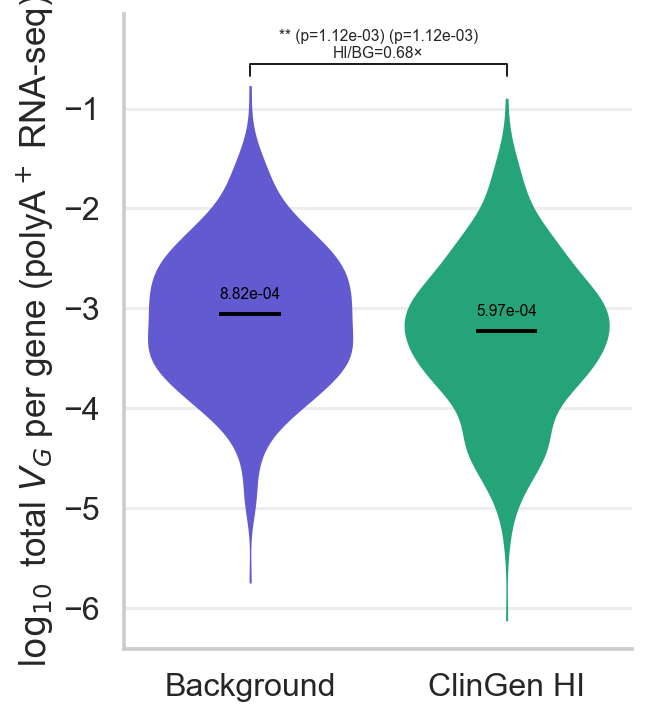

In [12]:
# ── 2-violin: observed only (main-text figure) ─────────────────────────────
obs_specs = [
    ('background', 'Background', SOURCE_PALETTE['background']),
    ('clingen',    'ClinGen HI', SOURCE_PALETTE['clingen']),
]

obs_df = (
    gene_df
    .to_pandas()
    .assign(
        log10_vg=lambda d: np.log10(np.clip(d['vg_predicted'].to_numpy(), VG_FLOOR, None)),
        dataset_label=lambda d: d['dataset_key'].map({k: lbl for k, lbl, _ in obs_specs}),
    )
)
label_order_obs  = [lbl for _, lbl, _ in obs_specs]
palette_obs      = {lbl: col for _, lbl, col in obs_specs}
obs_df['dataset_label'] = pd.Categorical(obs_df['dataset_label'], categories=label_order_obs, ordered=True)

obs_summary = (
    obs_df.groupby('dataset_label', observed=True)['vg_predicted']
    .median()
    .reset_index()
    .rename(columns={'vg_predicted': 'median_vg'})
)

fig, ax = plt.subplots(figsize=(4.5, 5), constrained_layout=True)

sns.violinplot(
    data=obs_df,
    x='dataset_label', y='log10_vg',
    hue='dataset_label',
    order=label_order_obs,
    palette=palette_obs,
    legend=False,
    inner=None, cut=0, linewidth=0,
    ax=ax,
)

# ── median line + label ──────────────────────────────────────────────────────
def _annotate_median(ax, index, median_value, *, text_color='black'):
    log_med = np.log10(max(median_value, VG_FLOOR))
    ax.hlines(log_med, index - 0.12, index + 0.12, colors=text_color, linewidth=2, zorder=4)
    ax.text(index, log_med + 0.12, f'{median_value:.2e}',
            ha='center', va='bottom', fontsize=8, color=text_color)

for idx, (_, lbl, _) in enumerate(obs_specs):
    med = obs_summary.loc[obs_summary['dataset_label'] == lbl, 'median_vg'].iat[0]
    _annotate_median(ax, idx, med)

# ── bracket ──────────────────────────────────────────────────────────────────
y_top = obs_df['log10_vg'].max()
y_low, y_high = y_top + 0.10, y_top + 0.22
ax.plot([0, 0, 1, 1], [y_low, y_high, y_high, y_low], color='black', lw=0.9, clip_on=False)
ax.text(0.5, y_high + 0.03,
        f'{sig_stars(p_value)} (p={p_value:.2e})\nHI/BG={median_ratio:.2f}×',
        ha='center', va='bottom', fontsize=8)

ax.set_ylim(top=y_top + 0.72)
ax.set_xlabel('')
ax.set_ylabel(r'$\log_{10}$ total $V_G$ per gene (polyA$^+$ RNA-seq)')
ax.grid(axis='x', visible=False)
sns.despine(ax=ax)

save_plot(fig=fig, title='4_2_total_vg_observed_only', notebook=NOTEBOOK_NAME, outdir=FIG_DIR)
plt.show()

[save_plot] Saved: 4_2_total_vg_global_comparison_4_2_total_vg_all_groups_supplementary_22052026_1245.pdf
[save_plot] Saved: 4_2_total_vg_global_comparison_4_2_total_vg_all_groups_supplementary_22052026_1245.svg


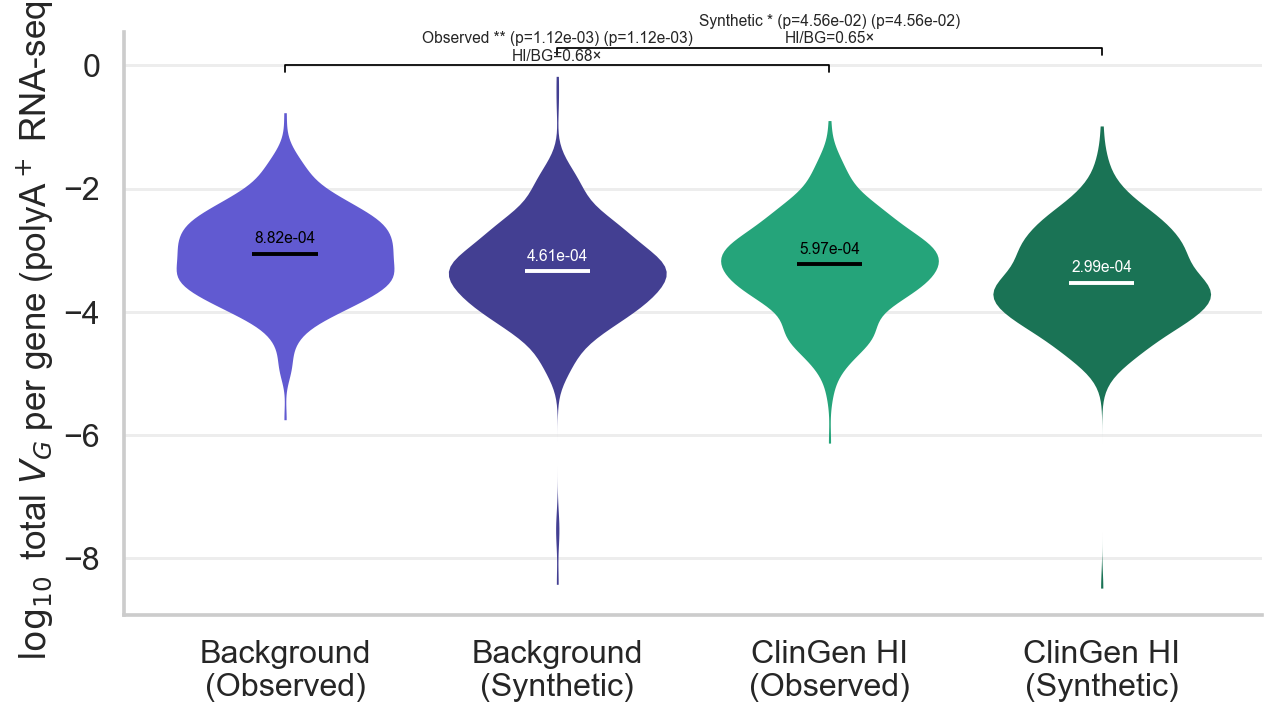

In [13]:
# ── 4-violin: observed + synthetic null (supplementary figure) ──────────────
def darken_hex(hex_color, factor=0.7):
    hex_color = hex_color.lstrip('#')
    rgb = [int(hex_color[i:i + 2], 16) for i in (0, 2, 4)]
    return '#' + ''.join(f'{max(0, min(255, round(c * factor))):02x}' for c in rgb)


plot_group_specs = [
    ('background',    'vg_predicted',      'Background\n(Observed)',  SOURCE_PALETTE['background']),
    ('background_null','vg_predicted_perm', 'Background\n(Synthetic)', darken_hex(SOURCE_PALETTE['background'])),
    ('clingen',        'vg_predicted',      'ClinGen HI\n(Observed)',  SOURCE_PALETTE['clingen']),
    ('clingen_null',   'vg_predicted_perm', 'ClinGen HI\n(Synthetic)', darken_hex(SOURCE_PALETTE['clingen'])),
]

plot_frames = []
for dataset_key, metric, dataset_label, _ in plot_group_specs:
    plot_frames.append(
        pl.read_parquet(GENE_PATHS[dataset_key], columns=['gene_id', metric])
        .rename({metric: 'vg'})
        .with_columns([
            pl.lit(dataset_key).alias('dataset_key'),
            pl.lit(dataset_label).alias('dataset_label'),
        ])
    )

plot_df       = pl.concat(plot_frames, how='vertical_relaxed').to_pandas()
label_order   = [lbl  for _, _, lbl, _   in plot_group_specs]
palette_dict  = {lbl: col for _, _, lbl, col in plot_group_specs}
plot_df['dataset_label'] = pd.Categorical(plot_df['dataset_label'], categories=label_order, ordered=True)
plot_df['log10_vg'] = np.log10(np.clip(plot_df['vg'].to_numpy(), VG_FLOOR, None))

vg_summary = (
    plot_df.groupby('dataset_label', observed=True)['vg']
    .median()
    .reset_index()
    .rename(columns={'vg': 'median_vg'})
)

synthetic_hi = plot_df.loc[plot_df['dataset_key'] == 'clingen_null',    'vg'].to_numpy()
synthetic_bg = plot_df.loc[plot_df['dataset_key'] == 'background_null', 'vg'].to_numpy()
synthetic_p_value = mannwhitneyu(synthetic_hi, synthetic_bg, alternative='two-sided').pvalue
synthetic_ratio   = float(np.median(synthetic_hi) / np.median(synthetic_bg))

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)

sns.violinplot(
    data=plot_df,
    x='dataset_label', y='log10_vg',
    hue='dataset_label',
    order=label_order,
    palette=palette_dict,
    legend=False,
    inner=None, cut=0, linewidth=0,
    ax=ax,
)

# ── median lines + labels ────────────────────────────────────────────────────
for idx, lbl in enumerate(label_order):
    med = vg_summary.loc[vg_summary['dataset_label'] == lbl, 'median_vg'].iat[0]
    log_med   = np.log10(max(med, VG_FLOOR))
    txt_color = 'white' if 'Synthetic' in lbl else 'black'
    ax.hlines(log_med, idx - 0.12, idx + 0.12, colors=txt_color, linewidth=2, zorder=4)
    ax.text(idx, log_med + 0.12, f'{med:.2e}',
            ha='center', va='bottom', fontsize=8, color=txt_color)

# ── significance brackets ─────────────────────────────────────────────────────
y_top = plot_df['log10_vg'].max()

def _bracket(x0, x1, y_low, y_high, label):
    ax.plot([x0, x0, x1, x1], [y_low, y_high, y_high, y_low],
            color='black', lw=0.9, clip_on=False)
    ax.text((x0 + x1) / 2, y_high + 0.03, label,
            ha='center', va='bottom', fontsize=8)

_bracket(0, 2, y_top + 0.07, y_top + 0.18,
         f'Observed {sig_stars(p_value)} (p={p_value:.2e})\nHI/BG={median_ratio:.2f}×')
_bracket(1, 3, y_top + 0.35, y_top + 0.46,
         f'Synthetic {sig_stars(synthetic_p_value)} (p={synthetic_p_value:.2e})\nHI/BG={synthetic_ratio:.2f}×')

ax.set_ylim(top=y_top + 0.72)
ax.set_xlabel('')
ax.set_ylabel(r'$\log_{10}$ total $V_G$ per gene (polyA$^+$ RNA-seq)')
ax.grid(axis='x', visible=False)
sns.despine(ax=ax)

save_plot(fig=fig, title='4_2_total_vg_all_groups_supplementary', notebook=NOTEBOOK_NAME, outdir=FIG_DIR)
plt.show()

In [14]:
print('=== 4.2 Total-Vg Summary (polyA+, SNPs only) ===')
depleted = median_ratio < 1
print(
    f"ClinGen HI median Vg = {med_hi:.4e}\n"
    f"Background median Vg  = {med_bg:.4e}\n"
    f"HI / BG ratio         = {median_ratio:.2f}x\n"
    f"Mann-Whitney p        = {p_value:.2e}\n"
    f"Rank-biserial r       = {rank_biserial:+.3f}\n"
    f"Direction             = {'ClinGen DEPLETED (HI < BG) ✓' if depleted else 'ClinGen ENRICHED (HI > BG)'}"
)

=== 4.2 Total-Vg Summary (polyA+, SNPs only) ===
ClinGen HI median Vg = 5.9688e-04
Background median Vg  = 8.8200e-04
HI / BG ratio         = 0.68x
Mann-Whitney p        = 1.12e-03
Rank-biserial r       = -0.146
Direction             = ClinGen DEPLETED (HI < BG) ✓
